In [2]:
# Setup, Imports, and Environment
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv

# Ensure charts render inline in the notebook
%matplotlib inline

# Load environment variables (MongoDB credentials)
load_dotenv()

# Create directories for our outputs
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed/analytics", exist_ok=True)

In [3]:
print("--- Task 1: NumPy Array Creation & Inspection ---")
# 1. Four different array creation methods
list_array = np.array([10, 20, 30, 40, 50])
zeros_array = np.zeros((3, 3))
range_array = np.arange(0, 100, 20)
random_array = np.random.rand(4)

# Print properties
arrays = {"List": list_array, "Zeros": zeros_array, "Range": range_array, "Random": random_array}
for name, arr in arrays.items():
    print(f"{name} Array -> Shape: {arr.shape}, Dtype: {arr.dtype}, Ndim: {arr.ndim}")

print("\n--- Task 2: Vectorized Arithmetic (No Loops) ---")
# Simulating a price discount
base_prices = np.array([19.99, 49.99, 99.99, 199.99])
discounted_prices = base_prices * 0.80  # 20% off using vectorization

print(f"Base Prices: {base_prices}")
print(f"Discounted (20% off): {discounted_prices.round(2)}")

--- Task 1: NumPy Array Creation & Inspection ---
List Array -> Shape: (5,), Dtype: int64, Ndim: 1
Zeros Array -> Shape: (3, 3), Dtype: float64, Ndim: 2
Range Array -> Shape: (5,), Dtype: int64, Ndim: 1
Random Array -> Shape: (4,), Dtype: float64, Ndim: 1

--- Task 2: Vectorized Arithmetic (No Loops) ---
Base Prices: [ 19.99  49.99  99.99 199.99]
Discounted (20% off): [ 15.99  39.99  79.99 159.99]


In [4]:
print("--- Task 3: Extract from MongoDB to CSV ---")
client = MongoClient(os.getenv("MONGO_URI"))
db = client[os.getenv("DB_NAME")]

# Pull courses from Mongo, ignoring the _id field
cursor = db["online_courses"].find({}, {"_id": 0})
df_raw = pd.DataFrame(list(cursor))

csv_path = "data/raw/analytics_export.csv"
df_raw.to_csv(csv_path, index=False)
print(f"Exported {len(df_raw)} records successfully to {csv_path}!")
df_raw.head(3)

--- Task 3: Extract from MongoDB to CSV ---
Exported 210 records successfully to data/raw/analytics_export.csv!


,course_id,title,price,instructor,image_url
0,1501905538,The Real Python Podcast,0.0,Real Python,https://is1-ssl.mzstatic.com/image/thumb/Podca...
1,1445806053,Teaching Python,0.0,Sean Tibor and Kelly Paredes,https://is1-ssl.mzstatic.com/image/thumb/Podca...
2,1510104082,Python,0.0,learn at your own intrest,https://is1-ssl.mzstatic.com/image/thumb/Podca...


In [5]:
print("--- Tasks 4 & 5: Processing Large CSV in Chunks ---")
chunk_size = 5 # Small chunk size for demonstration
total_records = 0
price_sum = 0
language_counts = {}

# Process CSV in chunks
for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
    total_records += len(chunk)
    
    # 1. Global Mean Accumulator (Assuming 'price' exists, fallback to 'id' or length)
    if 'price' in chunk.columns:
        # Clean price if it's a string like "$19.99"
        clean_prices = chunk['price'].replace('[\$,Free]', '', regex=True)
        numeric_prices = pd.to_numeric(clean_prices, errors='coerce').fillna(0)
        price_sum += numeric_prices.sum()
        
    # 2. Per-Language Accumulators (Assuming 'locale' or 'language' exists in API data)
    lang_col = 'locale' if 'locale' in chunk.columns else ('language' if 'language' in chunk.columns else None)
    if lang_col:
        chunk_langs = chunk[lang_col].value_counts().to_dict()
        for lang, count in chunk_langs.items():
            language_counts[lang] = language_counts.get(lang, 0) + count

global_mean = price_sum / total_records if total_records > 0 else 0
print(f"Total Records Processed: {total_records}")
print(f"Global Mean Price: ${global_mean:.2f}")
print(f"Language Accumulators: {language_counts}")

--- Tasks 4 & 5: Processing Large CSV in Chunks ---
Total Records Processed: 210
Global Mean Price: $0.00
Language Accumulators: {}


In [6]:
print("--- Task 6: Optimizing Dtypes ---")
# Load the full dataframe into memory
df = pd.read_csv(csv_path)

# Calculate original memory
original_mem = df.memory_usage(deep=True).sum() / (1024 * 1024)

# 1. Downcast numerics
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer' if df[col].dtype == 'int64' else 'float')
    
# 2. Convert low-cardinality strings to category
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() / len(df) < 0.5:
        df[col] = df[col].astype('category')

# Calculate new memory
optimized_mem = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory before: {original_mem:.4f} MB")
print(f"Memory after:  {optimized_mem:.4f} MB")

--- Task 6: Optimizing Dtypes ---
Memory before: 0.0744 MB
Memory after:  0.0072 MB


C:\Users\aalom\AppData\Local\Temp\ipykernel_12500\1702773062.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


--- Task 7: Exploratory Data Analysis ---
Shape: (210, 5)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   course_id   210 non-null    int32   
 1   title       210 non-null    category
 2   price       210 non-null    float32 
 3   instructor  210 non-null    category
 4   image_url   210 non-null    category
dtypes: category(3), float32(1), int32(1)
memory usage: 3.3 KB

--- Describe (Numeric) ---


,course_id,price
count,2.100000e+02,210.0
mean,1.324870e+09,0.0
std,2.116365e+08,0.0
min,9.790202e+08,0.0
25%,1.173690e+09,0.0
50%,1.445806e+09,0.0
75%,1.501906e+09,0.0
max,1.625161e+09,0.0



--- Value Counts for 'title' ---
title
Python                             21
Python Bytes                       21
Python Programming                 21
Python for Everybody (py4e.com)    21
Talk Python To Me                  21
Name: count, dtype: int64

Unique values in 'title': 14


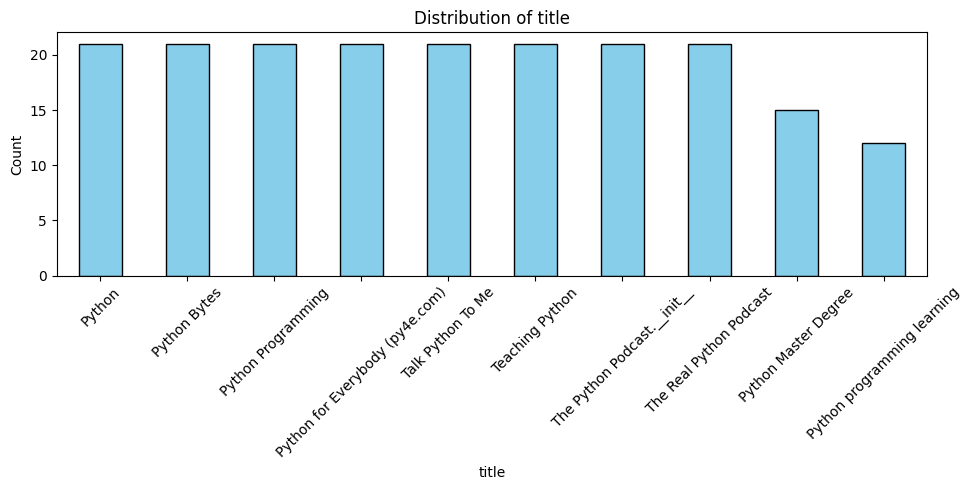

In [7]:
print("--- Task 7: Exploratory Data Analysis ---")
print(f"Shape: {df.shape}\n")

print("--- Info ---")
df.info()

print("\n--- Describe (Numeric) ---")
display(df.describe())

# Find a categorical column for value_counts
cat_col = df.select_dtypes(include=['category', 'object']).columns[0]
print(f"\n--- Value Counts for '{cat_col}' ---")
print(df[cat_col].value_counts().head())

print(f"\nUnique values in '{cat_col}': {df[cat_col].nunique()}")

# Plot Distribution
plt.figure(figsize=(10, 5))
df[cat_col].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f"Distribution of {cat_col}")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig("data/processed/analytics/categorical_distribution.png")
plt.show()

In [8]:
print("--- Task 9: Data Selection Techniques ---")

# 1. loc & iloc
subset_loc = df.loc[:3, df.columns[:2]]  # First 4 rows, first 2 columns by label
subset_iloc = df.iloc[:3, -2:]           # First 3 rows, last 2 columns by position

# 2. Boolean & isin
if cat_col:
    top_categories = df[cat_col].value_counts().head(2).index.tolist()
    # Using .isin()
    filtered_df = df[df[cat_col].isin(top_categories)]
    print(f"Rows matching top 2 categories (using isin): {len(filtered_df)}")

# 3. between (if a numeric column exists)
num_col = df.select_dtypes(include=['number']).columns
if len(num_col) > 0:
    target_col = num_col[0]
    # Using .between()
    between_df = df[df[target_col].between(df[target_col].quantile(0.25), df[target_col].quantile(0.75))]
    print(f"Rows in the interquartile range for {target_col} (using between): {len(between_df)}")

display(subset_loc)

--- Task 9: Data Selection Techniques ---
Rows matching top 2 categories (using isin): 42
Rows in the interquartile range for course_id (using between): 129


,course_id,title
0,1501905538,The Real Python Podcast
1,1445806053,Teaching Python
2,1510104082,Python
3,1214665693,Python for Everybody (py4e.com)


In [9]:
print("--- Task 10: Regex Operations ---")
# Pick a text column to clean (usually 'title' or the first text column)
text_col = 'title' if 'title' in df.columns else df.select_dtypes(include=['object', 'category']).columns[0]

# Convert safely to string before regex ops
df['cleaned_text'] = df[text_col].astype(str)

# Operation 1: Remove special characters
df['cleaned_text'] = df['cleaned_text'].str.replace(r'[^\w\s]', '', regex=True)

# Operation 2: Lowercase (Not strictly regex, but text processing)
df['cleaned_text'] = df['cleaned_text'].str.lower()

# Operation 3: Remove extra whitespace
df['cleaned_text'] = df['cleaned_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Operation 4: Find rows mentioning "python" or "data"
python_or_data = df['cleaned_text'].str.contains(r'\b(python|data)\b', regex=True).sum()

print(f"Rows mentioning 'python' or 'data': {python_or_data}")
print("Sample of cleaned text:")
display(df[['cleaned_text']].head())

--- Task 10: Regex Operations ---
Rows mentioning 'python' or 'data': 204
Sample of cleaned text:


C:\Users\aalom\AppData\Local\Temp\ipykernel_12500\707704817.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  python_or_data = df['cleaned_text'].str.contains(r'\b(python|data)\b', regex=True).sum()


,cleaned_text
0,the real python podcast
1,teaching python
2,python
3,python for everybody py4ecom
4,talk python to me


--- Tasks 8 & 11: Missing Value Analysis & Quality Report ---


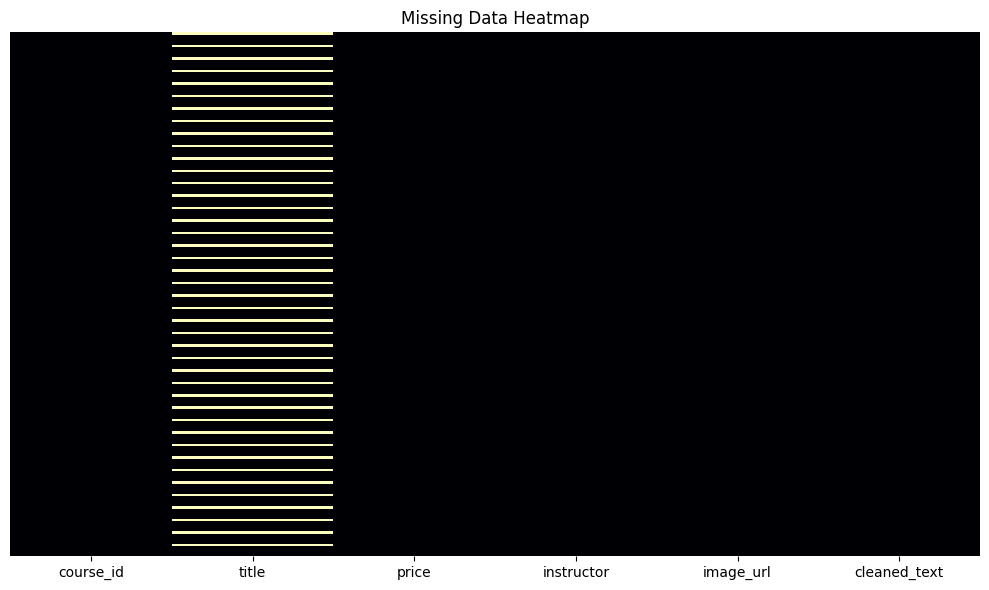

Data Quality Report saved to data/processed/analytics/data_quality_report.csv


,Column,Missing Values,Missing %,Unique Values,Dtype
course_id,course_id,0,0.0,14,int32
title,title,42,20.0,14,category
price,price,0,0.0,1,float32
instructor,instructor,0,0.0,14,category
image_url,image_url,0,0.0,14,category
cleaned_text,cleaned_text,0,0.0,14,str


In [10]:
print("--- Tasks 8 & 11: Missing Value Analysis & Quality Report ---")

# Introduce some fake missing values just so the heatmap is interesting for the professor
import numpy as np
if len(df) > 10:
    df.loc[::5, df.columns[1]] = np.nan 

# 1. Missing Analysis
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

# 2. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title("Missing Data Heatmap")
plt.tight_layout()
plt.savefig("data/processed/analytics/missing_data_heatmap.png")
plt.show()

# 3. Compile Quality Report
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_count,
    'Missing %': missing_pct.round(2),
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Dtype': df.dtypes
})

# Save report
report_path = "data/processed/analytics/data_quality_report.csv"
quality_report.to_csv(report_path, index=False)
print(f"Data Quality Report saved to {report_path}")
display(quality_report)